# Lag plots, autocorrelation, and white noise

The scatterplot lesson studied relationships *between* different time series. Now we turn to relationships *within* a single series — how each observation relates to its own past values.

In this lesson you will:

- build **lag plots** — scatterplots of $y_t$ against $y_{t-k}$;
- compute the **autocorrelation function** (ACF) and read a **correlogram**;
- recognise ACF patterns caused by **trend** and **seasonality**; and
- define **white noise** and use ACF significance bounds.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

# Docs: https://pandas.pydata.org/docs/ | https://seaborn.pydata.org/
# ACF:  https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.acf.html
#       https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html
sns.set_theme(style="whitegrid")

LESSON_DIR = Path().resolve()
DATA_DIR = LESSON_DIR.parent / "data"

## Serial dependence

A key feature of most time series is that adjacent observations tend to be correlated, i.e. **serially dependent**.

- The graphs discussed so far help us identify and visualise features of *individual* time series.
- In the previous lesson we studied relationships *between* multiple time series using scatterplots.
- Here we study how a series relates to **its own lagged values** using lag plots, the autocorrelation function (ACF), and the white-noise benchmark.

## Lag plots

Adapted from [§2.7](https://otexts.com/fpp3/lag-plots.html).

A **lag plot** is a scatterplot of $y_t$ against a lagged value of the same series, $y_{t-k}$. It shows how observations separated by $k$ periods relate to each other.

### The `aus_production` data

We use the `aus_production` dataset, stored as a plain CSV in `data/aus_production.csv`.

- Seven columns: six commodity series plus `Quarter`.
- Here we focus on quarterly **gas** production in petajoules.
- FPP3 uses beer production for this example; we use gas from the same dataset for the same quarterly seasonal pattern.
- Filter to quarters from **2000 onward**:

In [2]:
aus_production = pd.read_csv(DATA_DIR / "aus_production.csv")

# Quarters are stored as strings like "1956Q1"; PeriodIndex parses them into a
# proper quarterly time index — the same recipe works for any quarterly CSV.
aus_production["Quarter"] = pd.PeriodIndex(aus_production["Quarter"], freq="Q")
display(aus_production.head())

recent_production = aus_production.loc[
    aus_production["Quarter"].dt.year >= 2000
].copy()

gas = recent_production.set_index("Quarter")["Gas"]
print(f"Quarters from {gas.index.min()} to {gas.index.max()} ({len(gas)} observations)")

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas
0,1956Q1,284.0,5225.0,189.0,465.0,3923.0,5.0
1,1956Q2,213.0,5178.0,204.0,532.0,4436.0,6.0
2,1956Q3,227.0,5297.0,208.0,561.0,4806.0,7.0
3,1956Q4,308.0,5681.0,197.0,570.0,4418.0,6.0
4,1957Q1,262.0,5577.0,187.0,529.0,4339.0,5.0


Quarters from 2000Q1 to 2010Q2 (42 observations)


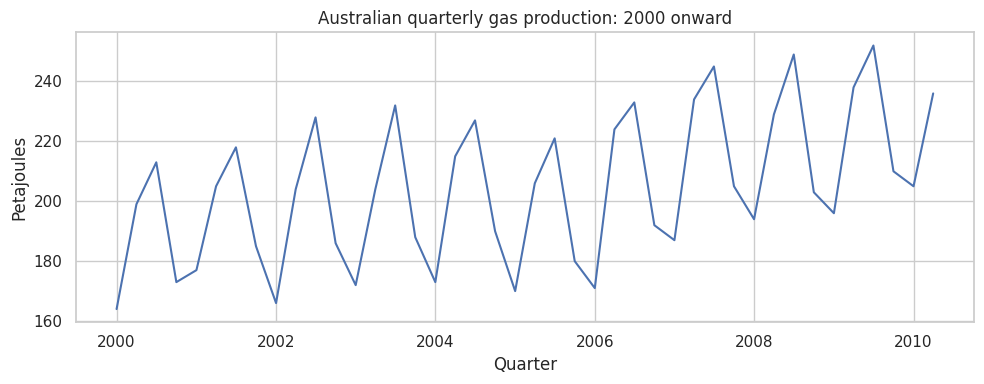

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

# matplotlib cannot place quarterly Periods on an axis directly;
# .to_timestamp() converts each period to the date it starts on.
sns.lineplot(
    x=gas.index.to_timestamp(),
    y=gas.to_numpy(),
    ax=ax,
)
ax.set(
    title="Australian quarterly gas production: 2000 onward",
    xlabel="Quarter",
    ylabel="Petajoules",
)
plt.tight_layout()
plt.show()

### Building the lag-plot grid

We build the grid from two standard ingredients:

- [`Series.shift(k)`](https://pandas.pydata.org/docs/reference/api/pandas.Series.shift.html) aligns each $y_t$ with $y_{t-k}$ in the same row — the universal pandas idiom for "compare a series with its own past";
- a loop over [`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) panels, drawing one [`sns.scatterplot`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) per lag.

The grid shows lags 1 through 9 — panel **lag = 1** plots $y_t$ against $y_{t-1}$, **lag = 2** plots $y_t$ against $y_{t-2}$, and so on.

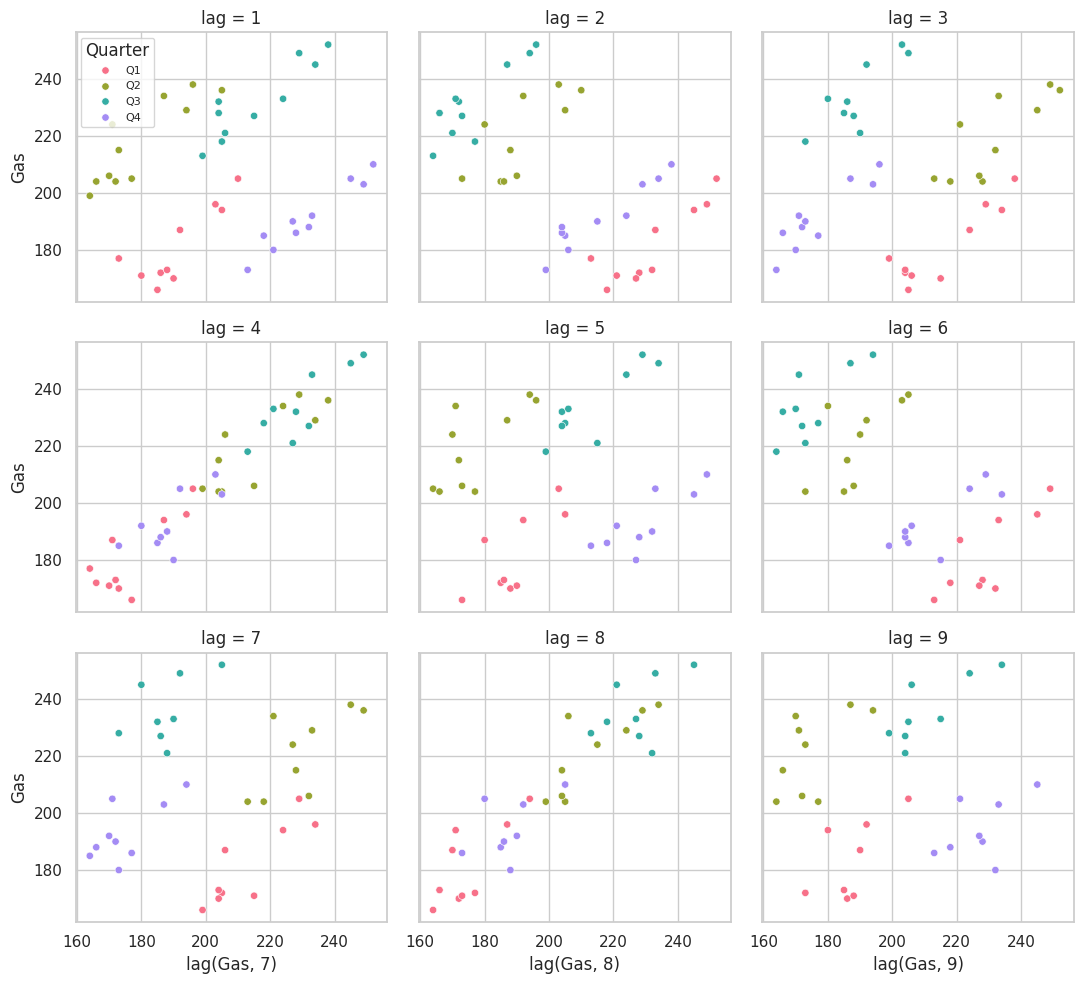

In [4]:
quarter_order = ["Q1", "Q2", "Q3", "Q4"]

fig, axes = plt.subplots(3, 3, figsize=(11, 10), sharex=True, sharey=True)

# Loop invariant: each panel compares y_t (vertical) with y_{t-k} (horizontal)
# for a different k. Reuse this recipe for any series — just swap `gas`.
for lag, axis in enumerate(axes.flatten(), start=1):
    panel = pd.DataFrame({
        # shift(k) moves values k rows forward, so row t holds y_{t-k}
        "lagged": gas.shift(lag),
        "Gas": gas,
        # colour by the quarter of y_t (the vertical axis)
        "quarter": "Q" + gas.index.quarter.astype(str),
    }).dropna()  # the first k rows have no lagged partner

    sns.scatterplot(
        data=panel,
        x="lagged",
        y="Gas",
        hue="quarter",
        hue_order=quarter_order,
        palette="husl",
        s=28,
        ax=axis,
        legend=(lag == 1),  # one legend for the whole grid
    )
    axis.set(title=f"lag = {lag}", xlabel=f"lag(Gas, {lag})")

axes[0, 0].legend(title="Quarter", fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

### Reading the colours

The colours indicate the **quarter** of the variable on the **vertical axis** ($y_t$), not the lagged value on the horizontal axis.

#### Lag = 1

In the **lag = 1** panel:

- **Q3** points plot quarter-three production on the vertical axis against quarter-two production of the *same year* on the horizontal axis.
- **Q1** points plot quarter-one production against quarter-four of the *previous* year — because the observation one quarter earlier falls in the previous calendar year.

Each colour traces how one seasonal quarter relates to the quarter immediately before it.

#### Lag = 2

In the **lag = 2** panel, each point compares $y_t$ with $y_{t-2}$:

- **Q3** points plot quarter-three values against quarter-*one* values of the same year.
- **Q1** points plot quarter-one values against quarter-three of the *previous* year.

### Seasonal patterns (Figure 2.19)

Looking across the grid:

- The relationship is **strongly positive at lags 4 and 8** — Q3 peaks align with Q3 peaks one and two years earlier.
- The relationship is **strongly negative at lags 2 and 6** — Q3 peaks are plotted against Q1 troughs, because seasonal peaks and troughs are two quarters apart.

This is exactly what we expect from a series with strong **quarterly seasonality**.

### Points versus lines

A scatterplot version draws each observation as a dot. Connecting points **in time order** within each quarter colour can reveal trajectories that dots alone hide.

In our Python grid the switch is small: replace `sns.scatterplot` with `sns.lineplot` (keeping `sort=False` so points stay in time order rather than being sorted by $x$).

For gas production the time ordering is not very instructive. For other series, however, the connected lines can reveal patterns that scatterpoints alone hide.

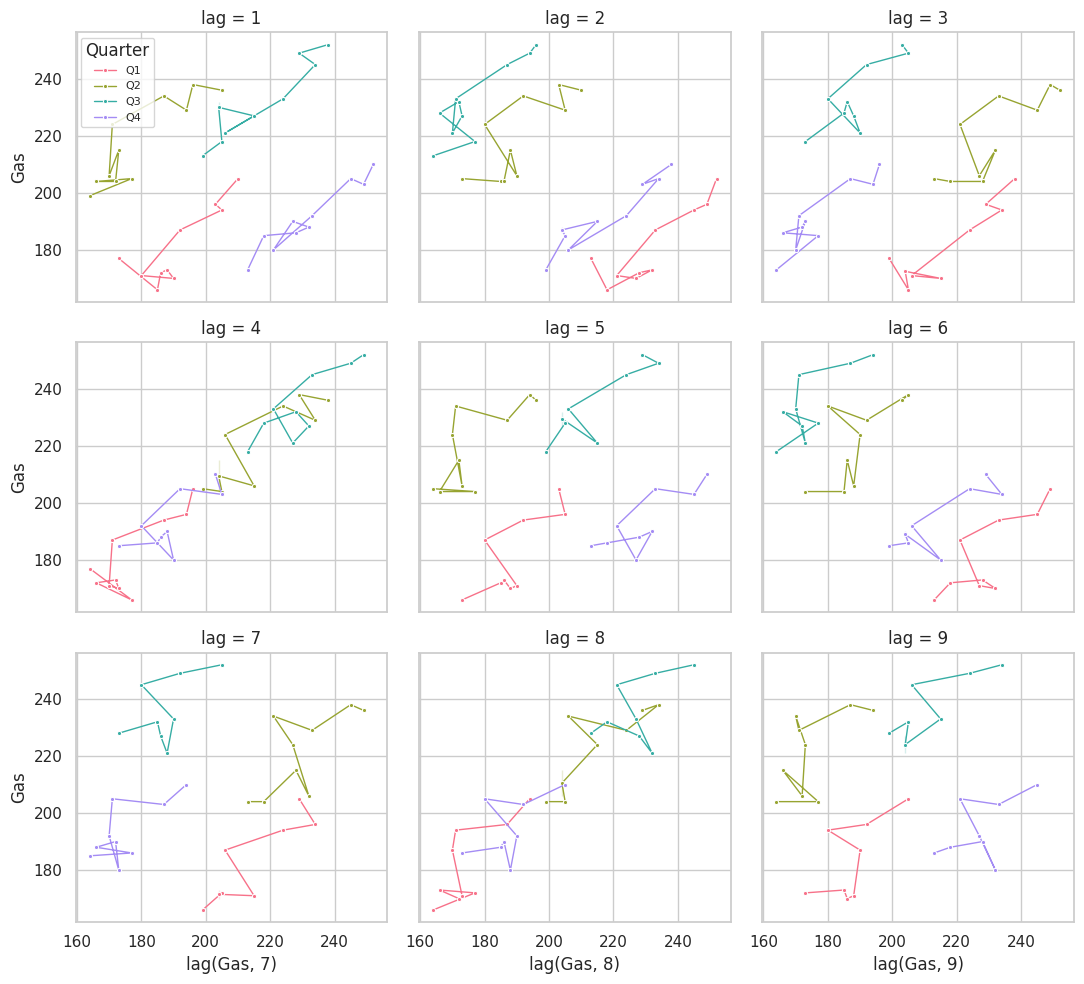

In [5]:
# Same grid as before; the only change is sns.lineplot instead of sns.scatterplot.
fig, axes = plt.subplots(3, 3, figsize=(11, 10), sharex=True, sharey=True)

for lag, axis in enumerate(axes.flatten(), start=1):
    panel = pd.DataFrame({
        "lagged": gas.shift(lag),
        "Gas": gas,
        "quarter": "Q" + gas.index.quarter.astype(str),
    }).dropna()

    # lineplot connects consecutive observations within each quarter colour,
    # revealing trajectories over the years that dots alone would hide.
    sns.lineplot(
        data=panel,
        x="lagged",
        y="Gas",
        hue="quarter",
        hue_order=quarter_order,
        palette="husl",
        linewidth=1,
        marker="o",
        markersize=3,
        sort=False,  # keep time order — sorting by x would scramble the trajectories
        ax=axis,
        legend=(lag == 1),
    )
    axis.set(title=f"lag = {lag}", xlabel=f"lag(Gas, {lag})")

axes[0, 0].legend(title="Quarter", fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Autocorrelation

Autocorrelation is one of the key tools for understanding a time series.

Return to the lag plots from the previous section:

- Each panel plotted $y_t$ against a lagged version of the same series, $y_{t-k}$.
- The ordinary correlation associated with each lag plot is called an **autocorrelation**.
- "Auto" means **self**: we are measuring how a series is related to itself at different distances in time.

### Autocorrelation coefficients

There are several autocorrelation coefficients, one for each lag:

- $r_1$ measures the relationship between $y_t$ and $y_{t-1}$.
- $r_2$ measures the relationship between $y_t$ and $y_{t-2}$.
- $r_k$ measures how observations $k$ periods apart relate to each other.

For the gas lag plots, the first panel has correlation $r_1$, the second panel has $r_2$, the third has $r_3$, and so on.

### Computing autocorrelation

We start with the sample autocovariance at lag $k$:

$$
\gamma_k = \frac{1}{T}\sum_{t=k+1}^{T}(y_t-\bar{y})(y_{t-k}-\bar{y}).
$$

Then we divide by the variance, $\gamma_0$, to get the autocorrelation:

$$
r_k = \frac{\gamma_k}{\gamma_0}
= \frac{\sum_{t=k+1}^T (y_t-\bar{y})(y_{t-k}-\bar{y})}
{\sum_{t=1}^T (y_t-\bar{y})^2}.
$$

This formula is slightly different from taking an ordinary sample correlation between $y_t$ and a shifted copy of $y_t$. Time-series software uses this convention because it gives better properties for ACF estimation.

The autocorrelation coefficients make up the **autocorrelation function** or **ACF**.

### Computing the ACF table

The result has one row per lag and an `acf` column containing the corresponding autocorrelation.

[`statsmodels.tsa.stattools.acf`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.acf.html) computes the coefficients using the time-series convention shown above. We wrap the result in a DataFrame for a readable table.

In [6]:
# acf() returns lags 0..nlags; coeffs[0] is always 1 (a series correlated with
# itself), so the table keeps lags 1..9 to match the nine lag-plot panels.
coeffs = acf(gas, nlags=9)

gas_acf = pd.DataFrame({
    "lag": [f"{k}Q" for k in range(1, 10)],  # label lags in quarters
    "acf": coeffs[1:],
})
display(gas_acf.round(4))

,lag,acf
0,1Q,0.1926
1,2Q,-0.4956
2,3Q,0.2351
3,4Q,0.8262
4,5Q,0.1042
5,6Q,-0.5165
6,7Q,0.1500
7,8Q,0.6944
8,9Q,0.0270


The values in the `acf` column are $r_1,\dots,r_9$, corresponding to the nine scatterplots in Figure 2.19.

We usually plot the ACF to see how the correlations change with the lag $k$. The plot is sometimes known as a **correlogram**.

If we do not limit the number of lags, `plot_acf` chooses a longer default. For quarterly gas production, the positive spikes repeat at seasonal lags: 4, 8, 12, 16, and so on.

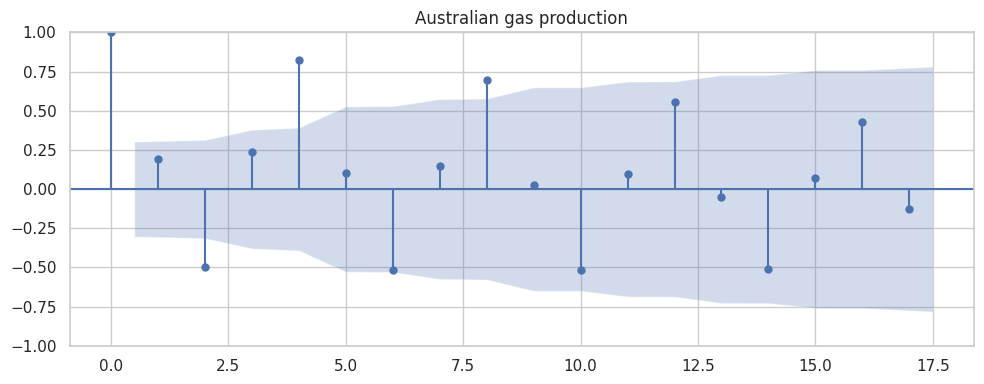

In [7]:
_, ax = plt.subplots(figsize=(10, 4))

# plot_acf works on any 1-D series: raw data now, model residuals later.
plot_acf(
    gas,
    ax=ax,
    alpha=0.05,  # draws the ±1.96/√T significance bands (the white-noise benchmark)
    title="Australian gas production",
)
plt.tight_layout()
plt.show()

### Reading the gas correlogram (Figure 2.20)

In this graph:

- $r_4$ and $r_8$ are strongly positive because they are multiples of the seasonal period. Peaks line up with peaks, and troughs line up with troughs.
- $r_2$ and $r_6$ are strongly negative because peaks are plotted against troughs.
- The dashed blue lines indicate whether the correlations are significantly different from zero (as explained in [§2.9 White noise](https://otexts.com/fpp3/wn.html)).

### A generations analogy

Another way to read an ACF is to imagine each observation as a generation.

- **Lag 1** compares each observation with its "parent" — the previous observation.
- **Lag 2** compares each observation with its "grandparent" — two periods earlier.
- **Lag 3** compares each observation with its "great-grandparent".
- **Lag 4** compares each observation with something four generations back.

For quarterly gas production, lag 4 compares each quarter with the same quarter in the previous year. That is why lag 4 is much more similar than lag 2.

### Trend and seasonality in ACF plots

Patterns in the data show up as patterns in the ACF.

- When data have a **trend**, the autocorrelations for small lags tend to be large and positive because observations nearby in time are also nearby in value. The ACF of a trended series often starts high and decreases slowly.
- When data are **seasonal**, the autocorrelations are larger at seasonal lags — the multiples of the seasonal period.
- When data are both trended and seasonal, the ACF combines both effects: slow decay from the trend, plus a repeating scalloped shape from seasonality.

The `a10` data plotted in Figure 2.2 shows both trend and seasonality. Its ACF is shown in Figure 2.21.

In [8]:
# Monthly antidiabetic drug sales; Cost is in millions of dollars.
a10 = pd.read_csv(
    DATA_DIR / "a10.csv",
    parse_dates=["Month"],
    index_col="Month",
)
display(a10.head())

,TotalC,Cost
Month,,
1991-07-01,3526591.0,3.526591
1991-08-01,3180891.0,3.180891
1991-09-01,3252221.0,3.252221
1991-10-01,3611003.0,3.611003
1991-11-01,3565869.0,3.565869


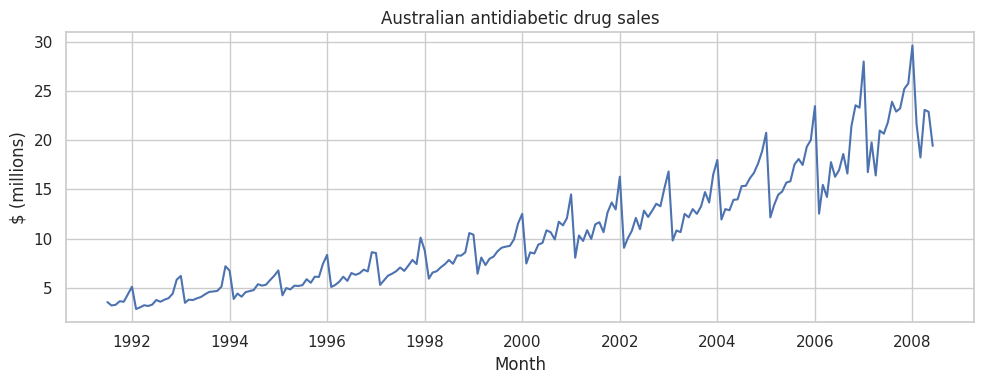

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    x=a10.index,
    y=a10["Cost"],
    ax=ax,
)
ax.set(
    title="Australian antidiabetic drug sales",
    xlabel="Month",
    ylabel="$ (millions)",
)
plt.tight_layout()
plt.show()

#### Reading the `a10` time plot (Figure 2.2)

- There is a clear and increasing **trend**.
- There is also a strong **seasonal pattern** that increases in size as the level of the series increases.
- The sudden drop at the start of each year is caused by a government subsidisation scheme that makes it cost-effective for patients to stockpile drugs at the end of the calendar year.

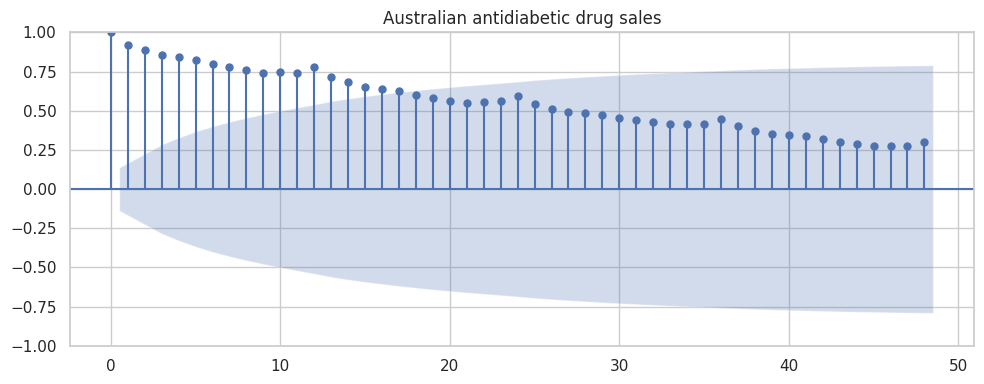

In [10]:
_, ax = plt.subplots(figsize=(10, 4))
plot_acf(
    a10["Cost"],
    lags=48,  # 4 years of monthly lags — enough to see seasonal bumps at 12, 24, 36, 48
    ax=ax,
    alpha=0.05,
    title="Australian antidiabetic drug sales",
)
plt.tight_layout()
plt.show()

### Example: US retail employment

US retail employment is monthly data with both trend and seasonality.

- Employment generally rises over time.
- There is a regular annual peak.
- The ACF should therefore stay positive for many lags, with small bumps near seasonal lags 12, 24, 36, and 48.

,Title,Employed
Month,,
1990-01-01,Retail Trade,13255.8
1990-02-01,Retail Trade,12966.3
1990-03-01,Retail Trade,12938.2
1990-04-01,Retail Trade,13012.3
1990-05-01,Retail Trade,13108.3


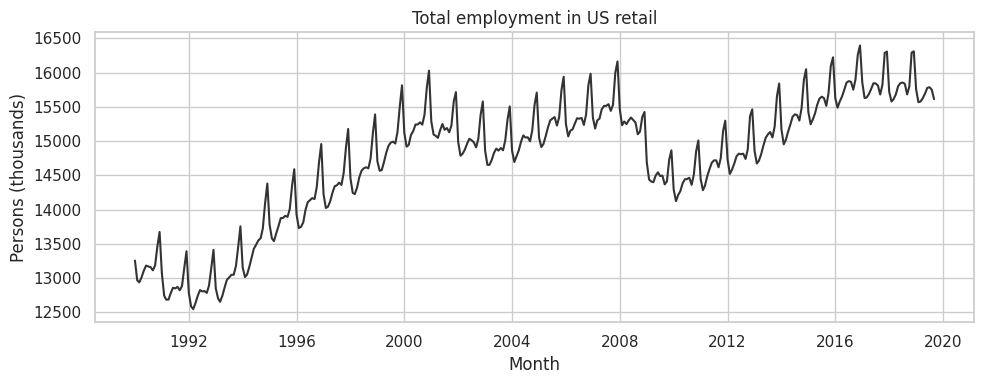

In [11]:
us_retail_employment = pd.read_csv(
    DATA_DIR / "us_retail_employment.csv",
    parse_dates=["Month"],
    index_col="Month",
)
display(us_retail_employment.head())

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    x=us_retail_employment.index,
    y=us_retail_employment["Employed"],
    ax=ax,
    color="#333333",
)
ax.set(
    title="Total employment in US retail",
    xlabel="Month",
    ylabel="Persons (thousands)",
)
plt.tight_layout()
plt.show()

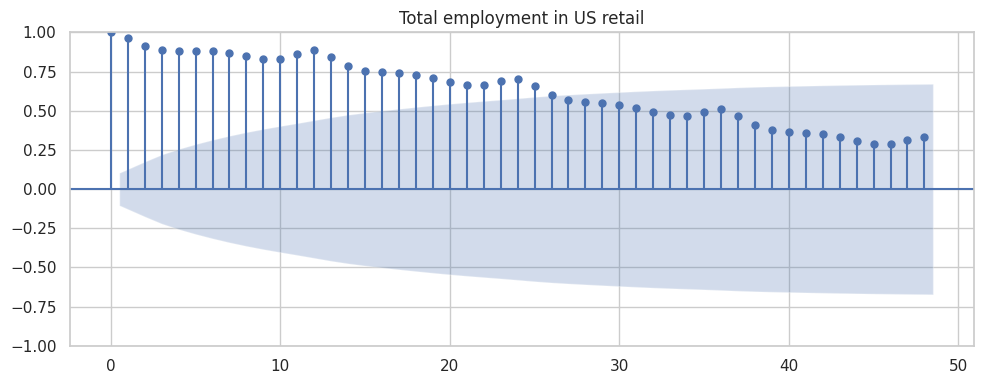

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(
    us_retail_employment["Employed"],
    lags=48,
    ax=ax,
    alpha=0.05,
    title="Total employment in US retail",
)
plt.tight_layout()
plt.show()

### Example: Google stock prices

Google daily closing prices in 2015 have no regular seasonal cycle, but they are strongly persistent.

- Stock prices on neighboring trading days tend to be close together.
- The ACF starts near one and decays slowly.
- This is typical of stock-price levels and many trended series.

The dates are irregular because weekends and market holidays are missing.

,Symbol,Date,Open,High,Low,Close,Adj_Close,Volume
0,GOOG,2015-01-02,526.114746,528.362366,521.231628,521.937744,521.937744,1447600.0
1,GOOG,2015-01-05,520.396240,521.460388,510.252045,511.057617,511.057617,2059800.0
2,GOOG,2015-01-06,512.181458,513.350037,498.307800,499.212799,499.212799,2899900.0
3,GOOG,2015-01-07,504.225220,504.467896,496.915436,498.357513,498.357513,2065100.0
4,GOOG,2015-01-08,495.264526,500.724487,488.312805,499.928864,499.928864,3353600.0


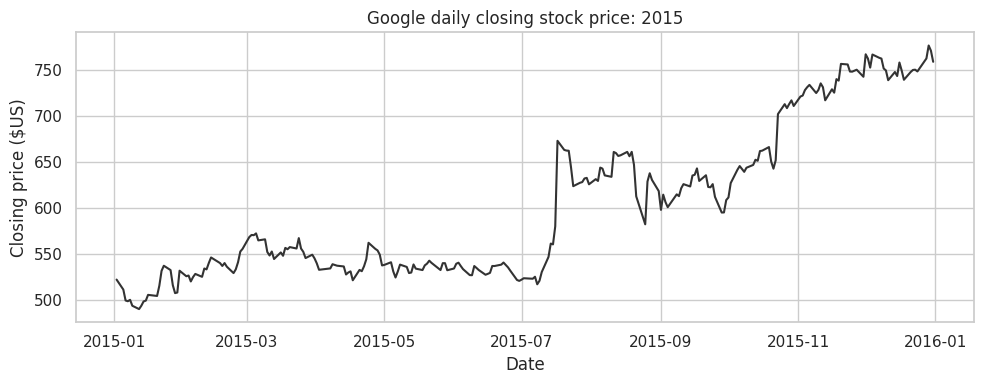

In [13]:
# Daily Google (GOOG) prices for 2015, pre-filtered from the gafa_stock dataset.
google_2015 = pd.read_csv(
    DATA_DIR / "gafa_stock_goog_2015.csv",
    parse_dates=["Date"],
)

display(google_2015.head())

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=google_2015,
    x="Date",
    y="Close",
    ax=ax,
    color="#333333",
)
ax.set(
    title="Google daily closing stock price: 2015",
    xlabel="Date",
    ylabel="Closing price ($US)",
)
plt.tight_layout()
plt.show()

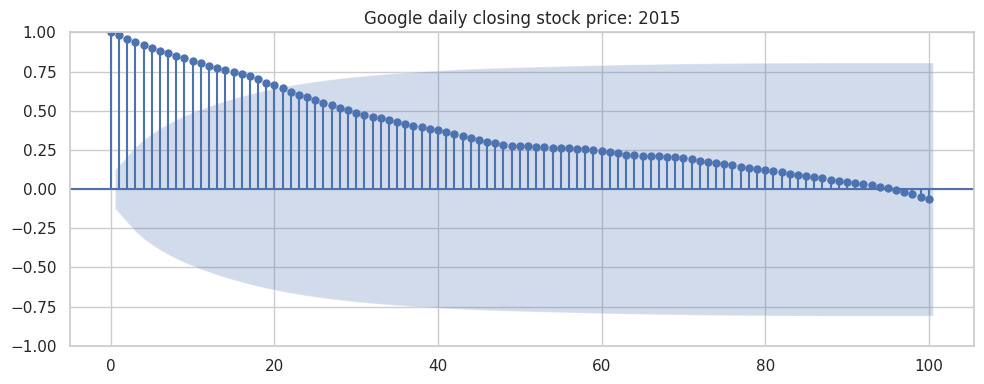

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(
    google_2015["Close"],
    lags=100,  # a long horizon shows how slowly a trended series decays
    ax=ax,
    alpha=0.05,
    title="Google daily closing stock price: 2015",
)
plt.tight_layout()
plt.show()

ACF plots are useful for raw time series, and even more useful later when we inspect **model residuals**. A residual ACF can reveal leftover structure that is hard to see in a time plot.

## White noise

The most boring time series in forecasting is **white noise**.

The name comes from signal processing:

- White light contains all frequencies.
- White noise contains all frequencies in the spectrum.
- If you think of a time series as an audio signal, white noise is the static hiss from an untuned radio.

### What is white noise?

Statistically, white noise is a sequence of **independent and identically distributed** random values.

White noise data are:

- uncorrelated across time,
- have zero mean,
- have constant variance.

In general we also require independence. For Gaussian white noise, uncorrelated values are automatically independent.

Figure 2.22 gives a simulated example with a fixed random seed and 50 standard normal values.

In [15]:
# A seeded generator makes the "random" example reproducible.
rng = np.random.default_rng(30)
y = pd.DataFrame({
    "sample": np.arange(1, 51),
    "wn": rng.normal(size=50),
}).set_index("sample")

display(y.head())

,wn
sample,
1,1.574641
2,0.743283
3,-0.969889
4,-0.212004
5,-0.286730


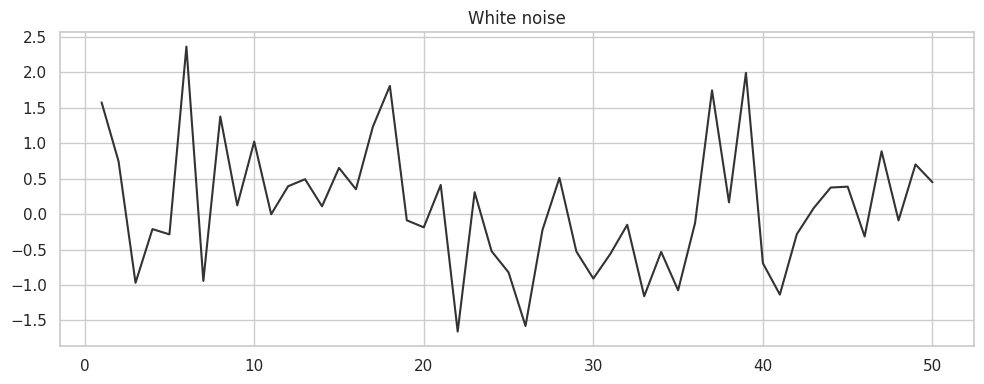

In [16]:
_, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=y,
    x=y.index,
    y="wn",
    ax=ax,
    color="#333333",
)
ax.set(title="White noise", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

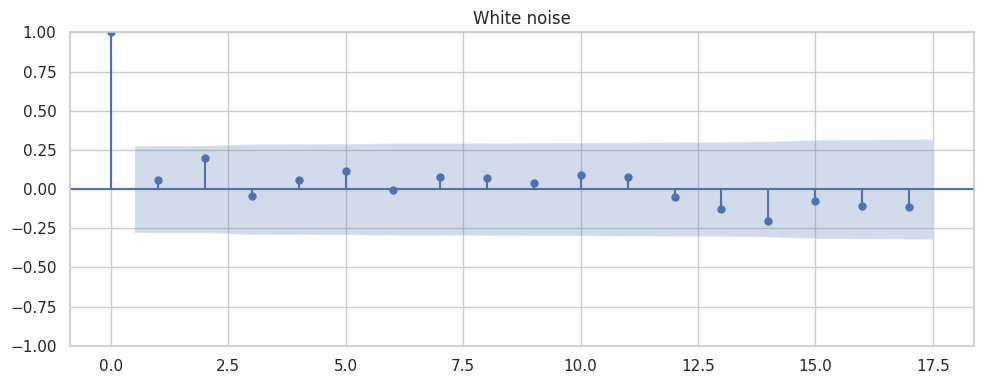

In [17]:
_, ax = plt.subplots(figsize=(10, 4))
# Even for pure noise, expect ~5% of spikes outside the bands by chance alone.
plot_acf(
    y["wn"],
    ax=ax,
    alpha=0.05,
    title="White noise",
)
plt.tight_layout()
plt.show()

### ACF significance bounds

Even when there is no true autocorrelation, a sample ACF will show some positive and negative spikes simply because of randomness.

For white noise, we expect sample autocorrelations to be close to zero.

When the series really is white noise and $T$ is large enough, each sample autocorrelation $r_k$ is approximately

$$
\mathcal{N}\!\left(0, \frac{1}{T}\right).
$$

So 95% of the time we expect

$$
r_k \in \left[-\frac{1.96}{\sqrt{T}}, +\frac{1.96}{\sqrt{T}}\right].
$$

These are the blue dashed lines on an ACF plot. About 5% of spikes may fall outside the bands even for genuine white noise.

If many spikes lie outside the bands — or if one spike is far outside — the series is probably **not** white noise.

In [18]:
T = len(y)

# Under white noise, r_k ~ N(0, 1/T); norm.ppf(0.975) = 1.96 is the 95% critical value.
# This is exactly the formula behind the dashed bands drawn by plot_acf.
bound = norm.ppf(0.975) / np.sqrt(T)
print(f"T = {T}")
print(f"95% significance bound: ±{bound:.2f}")

# Recompute the coefficients numerically to count spikes outside the bands.
wn_coeffs = acf(y["wn"], nlags=16)
wn_acf = pd.DataFrame({
    "lag": range(1, len(wn_coeffs)),
    "acf": wn_coeffs[1:],  # skip lag 0, which is always 1
})

outside = wn_acf.loc[wn_acf["acf"].abs() > bound]
print(f"Spikes outside bounds: {len(outside)} of {len(wn_acf)} ({100 * len(outside) / len(wn_acf):.1f}%)")
display(outside if not outside.empty else "All autocorrelation coefficients lie within the limits.")

T = 50
95% significance bound: ±0.28
Spikes outside bounds: 0 of 16 (0.0%)


'All autocorrelation coefficients lie within the limits.'

In this example, $T=50$, so the bounds are $\pm 1.96/\sqrt{50} \approx \pm 0.28$. All spikes up to lag 16 lie within the bands, which is what we expect for white noise.

### Example: sheep slaughter in Victoria

A time plot alone can be misleading.

We use monthly sheep slaughter in Victoria from `data/aus_livestock_vic_sheep.csv`, from 2014 to the end of 2018, scaled to thousands. The series looks fairly random — no obvious trend or seasonality — but an ACF plot is a better test.

Month
2014-01-01    352.4
2014-02-01    424.5
2014-03-01    362.6
2014-04-01    259.7
2014-05-01    291.9
Name: Count, dtype: float64

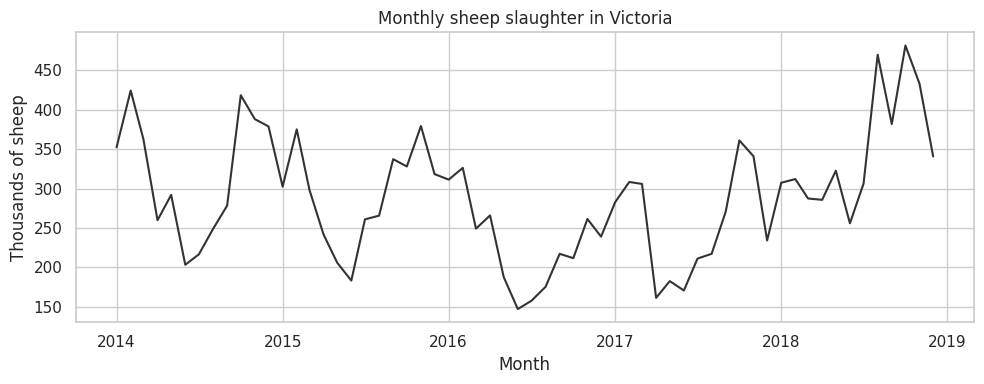

In [19]:
# Monthly sheep slaughter counts for Victoria.
vic_sheep = pd.read_csv(
    DATA_DIR / "aus_livestock_vic_sheep.csv",
    parse_dates=["Month"],  # months stored as "1972-07" parse straight to datetimes
)

vic_sheep = vic_sheep.loc[
    (vic_sheep["Month"].dt.year >= 2014)
    & (vic_sheep["Month"].dt.year <= 2018)
]

# Scale to thousands so the y-axis stays readable.
sheep_slaughter = (vic_sheep.set_index("Month")["Count"] / 1000).sort_index()

display(sheep_slaughter.head())

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    x=sheep_slaughter.index,
    y=sheep_slaughter.to_numpy(),
    ax=ax,
    color="#333333",
)
ax.set(
    title="Monthly sheep slaughter in Victoria",
    xlabel="Month",
    ylabel="Thousands of sheep",
)
plt.tight_layout()
plt.show()

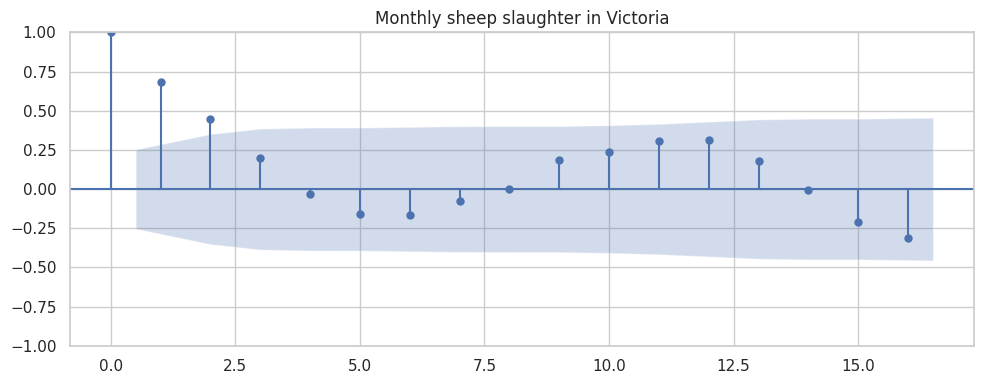

,lag,acf
0,1,0.680897
1,2,0.445127
10,11,0.305585
11,12,0.311215
15,16,-0.310180


In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(
    sheep_slaughter,
    lags=16,
    ax=ax,
    alpha=0.05,
    title="Monthly sheep slaughter in Victoria",
)
plt.tight_layout()
plt.show()

# Same white-noise test as before, on real data: which lags exceed ±1.96/√T?
bound = norm.ppf(0.975) / np.sqrt(len(sheep_slaughter))
sheep_coeffs = acf(sheep_slaughter, nlags=16)
sheep_acf = pd.DataFrame({
    "lag": range(1, len(sheep_coeffs)),
    "acf": sheep_coeffs[1:],
})
outside = sheep_acf.loc[sheep_acf["acf"].abs() > bound]
display(outside)

Several of the first 16 spikes lie outside the blue bands. The clearest signal is at **lag 12** — the seasonal lag for monthly data — which suggests leftover seasonality that is hard to see in the time plot. The series does **not** appear to be white noise.

When reading an ACF, do not over-interpret every small bump. Focus on spikes that are clearly outside the blue lines, especially when several spikes exceed the bounds or when a large spike occurs at a seasonal lag.

### Reusing these recipes

- **Lag plots for any series:** keep the `shift(k)` + subplot-loop structure; change the hue column to match the frequency (month names for monthly data, `"Q" + quarter` for quarterly).
- **White-noise test for any data:** run `plot_acf(series, alpha=0.05)` and count spikes outside the dashed bands — later in the course you will apply exactly this test to *model residuals*.
- **The three functions to remember:** `Series.shift` (align a series with its past), `statsmodels.tsa.stattools.acf` (the numbers), `statsmodels.graphics.tsaplots.plot_acf` (the picture).